In [1]:
import os
import numpy as np
from PIL import Image
import torch
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torchvision.transforms as T
import concurrent.futures

# Paths
input_dir = "/home/adeel/realestate50k/RealEstate10K-subset/train/frames/"
rgb_out_dir = "/data/adeel/Indoor_MetaData/rgb/"
depth_out_dir = "/data/adeel/Indoor_MetaData/depth/"

os.makedirs(rgb_out_dir, exist_ok=True)
os.makedirs(depth_out_dir, exist_ok=True)

# Recursively collect all .png images from all subfolders
img_paths = []
for root, _, files in os.walk(input_dir):
    for f in sorted(files):
        if f.lower().endswith('.png'):
            img_paths.append(os.path.join(root, f))

print(f"Total images to process: {len(img_paths)}")

# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = AutoImageProcessor.from_pretrained("xingyang1/Distill-Any-Depth-Large-hf", use_fast=False)
model = AutoModelForDepthEstimation.from_pretrained("xingyang1/Distill-Any-Depth-Large-hf").to(device)

resize = T.Resize((384, 640))

def load_and_resize(path):
    img = Image.open(path).convert("RGB")
    return resize(img)

batch_size = 128
num_batches = (len(img_paths) + batch_size - 1) // batch_size

for batch_idx in range(num_batches):
    batch_paths = img_paths[batch_idx*batch_size : (batch_idx+1)*batch_size]
    print(f"Processing batch {batch_idx+1}/{num_batches} ({len(batch_paths)} images)...")
    with concurrent.futures.ThreadPoolExecutor() as executor:
        imgs_resized = list(executor.map(load_and_resize, batch_paths))

    # Save resized RGB images as PNG with RS50 naming
    for i, img_resized in enumerate(imgs_resized):
        global_idx = batch_idx*batch_size + i + 1
        rgb_save_path = os.path.join(rgb_out_dir, f"RS50_{global_idx:07d}.png")
        img_resized.save(rgb_save_path)

    # Prepare batch input for model
    inputs = processor(images=imgs_resized, return_tensors="pt").to(device)
    print(f"Input tensor batch shape: {inputs['pixel_values'].shape}")
    with torch.no_grad():
        outputs = model(**inputs)

    # Depth maps (post-processed, no normalization)
    post = processor.post_process_depth_estimation(outputs, target_sizes=[(384, 640)]*len(imgs_resized))

    for i, depth_dict in enumerate(post):
        global_idx = batch_idx*batch_size + i + 1
        depth_map = depth_dict["predicted_depth"].cpu().numpy().astype(np.float32)
        depth_norm = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min() + 1e-8)
        depth_img = (depth_norm * 255).astype(np.uint8)
        depth_png_path = os.path.join(depth_out_dir, f"RS50_{global_idx:07d}_depth.png")
        Image.fromarray(depth_img).save(depth_png_path)

print(f"✅ Done! RS50 RGB and depth visualization (.png) images saved for all images in {input_dir}.")


/home/adeel/anaconda3/envs/distill_any_depth/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-10 23:31:25.010546: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-10 23:31:25.047236: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-10 23:31:25.010546: I tensorflow/core/util/port.cc:113] oneDNN custom opera

Total images to process: 27139
Processing batch 1/213 (128 images)...
Processing batch 1/213 (128 images)...
Input tensor batch shape: torch.Size([128, 3, 308, 518])
Input tensor batch shape: torch.Size([128, 3, 308, 518])
Processing batch 2/213 (128 images)...
Processing batch 2/213 (128 images)...
Input tensor batch shape: torch.Size([128, 3, 308, 518])
Input tensor batch shape: torch.Size([128, 3, 308, 518])
Processing batch 3/213 (128 images)...
Processing batch 3/213 (128 images)...
Input tensor batch shape: torch.Size([128, 3, 308, 518])
Input tensor batch shape: torch.Size([128, 3, 308, 518])
Processing batch 4/213 (128 images)...
Processing batch 4/213 (128 images)...
Input tensor batch shape: torch.Size([128, 3, 308, 518])
Input tensor batch shape: torch.Size([128, 3, 308, 518])
Processing batch 5/213 (128 images)...
Processing batch 5/213 (128 images)...
Input tensor batch shape: torch.Size([128, 3, 308, 518])
Input tensor batch shape: torch.Size([128, 3, 308, 518])
Processin

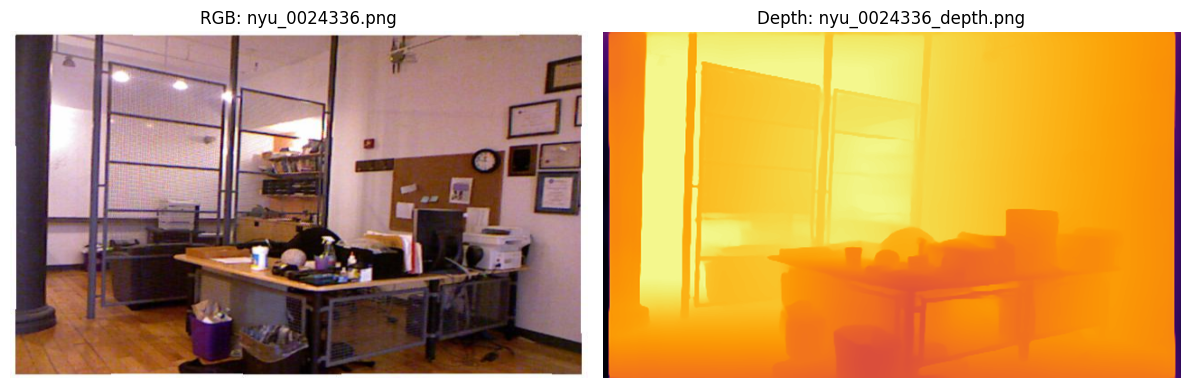

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

# Output folders
rgb_out_dir = "/data/adeel/Indoor_MetaData/rgb/"
depth_out_dir = "/data/adeel/Indoor_MetaData/depth/"

# List available RGB and depth images
rgb_files = sorted([f for f in os.listdir(rgb_out_dir) if f.endswith('.png')])
depth_files = sorted([f for f in os.listdir(depth_out_dir) if f.endswith('_depth.png')])

if not rgb_files or not depth_files:
    print("No RGB or depth images found in the output folders.")
else:
    # Randomly select one index (assuming matching order)
    idx = random.randint(0, min(len(rgb_files), len(depth_files)) - 1)
    rgb_file = rgb_files[idx]
    depth_file = depth_files[idx]

    rgb_path = os.path.join(rgb_out_dir, rgb_file)
    depth_path = os.path.join(depth_out_dir, depth_file)

    # Load images
    rgb_img = Image.open(rgb_path)
    depth_img = Image.open(depth_path)

    # Display
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(rgb_img)
    axs[0].set_title(f'RGB: {rgb_file}')
    axs[0].axis('off')
    axs[1].imshow(depth_img, cmap='inferno_r')
    axs[1].set_title(f'Depth: {depth_file}')
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()
